# Weekly project part 1
Using the image "appletree.jpg"
1) Can you segment the apples from the tree?
2) Can you get the computer to count how many there are? 
    How close can you get to the ground truth? (there are 26 apples in the image)
3) Can you change the color of one of them?
4) Can you segment the leaves?
    
    
# Weekly project part 2
1) Remove the greenscreen and replace the background in "itssp.png".
2) Can you improve the edge with eroding/dilating?


1) Can you segment the apples from the tree?

2) Can you get the computer to count how many there are? 
    How close can you get to the ground truth? (there are 26 apples in the image)

In [140]:
import cv2
import numpy as np
import imutils
from matplotlib import pyplot as plt

In [141]:
path = "appletree.jpg"

width=1600, height=1200, depth=3


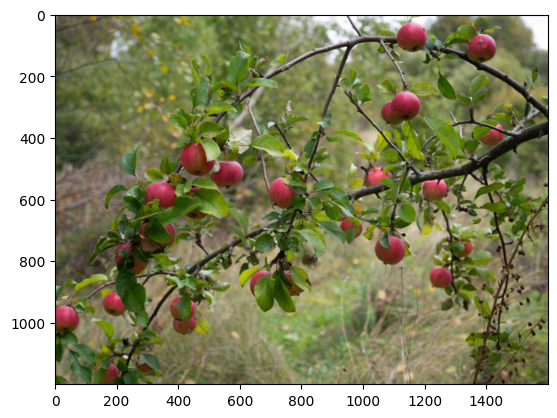

In [142]:
bgr_img = cv2.imread(path)

b,g,r = cv2.split(bgr_img)       # get b,g,r
image = cv2.merge([r,g,b])
(h, w, d) = image.shape
print("width={}, height={}, depth={}".format(w, h, d))
plt.imshow(image)

In [143]:
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

x, y = 0, 1000  
print("HSV at (x,y):", hsv[y, x])

HSV at (x,y): [113 173 118]


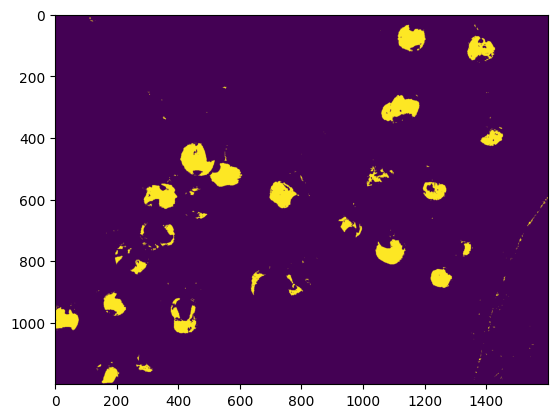

In [144]:
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

lower = (100, 150, 70)
upper = (170, 255, 255)
mask = cv2.inRange(hsv, lower, upper)

plt.imshow(mask)


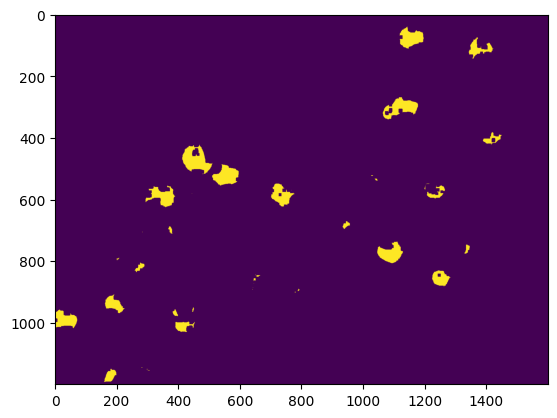

In [145]:
mask1 = cv2.erode(mask, None, iterations = 4)
plt.imshow(mask1)

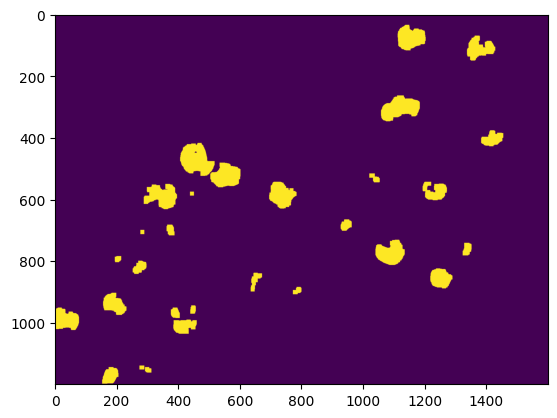

In [146]:
mask2 = cv2.dilate(mask1, None, iterations = 6)
plt.imshow(mask2)

I found 29 apples in the image


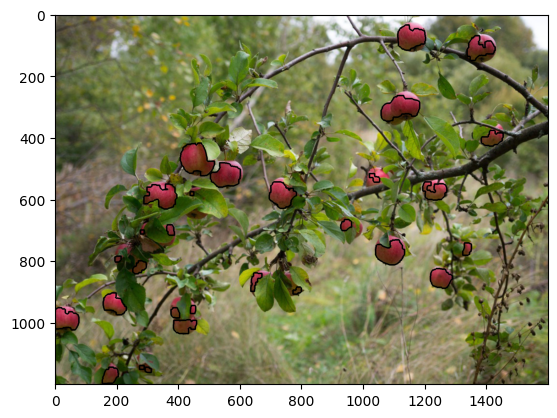

In [147]:
cnts = cv2.findContours(mask2, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cnts = imutils.grab_contours(cnts)
output = image.copy()
for c in cnts:
    # draw each contour on the output image with a 3px thick black outline
    cv2.drawContours(output, [c], -1, (0, 0, 0), 3)
    
plt.imshow(output)
print("I found {} apples in the image".format(len(cnts)))

3) Can you change the color of one of them?

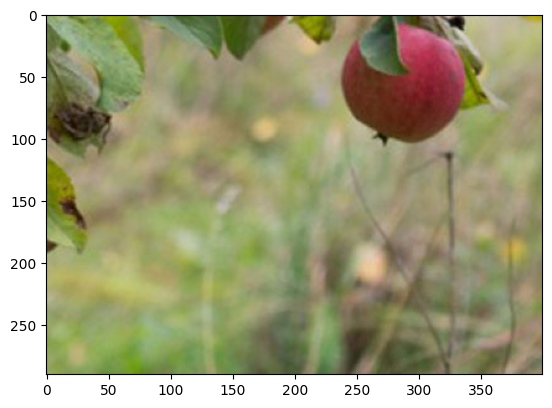

In [148]:
output1=image.copy()  # Select a region (y1:y2, x1:x2) → change values to yellow
section=output1[710:1000, 800:1200]  # BGR format → Yellow

# Show result
plt.imshow( section)

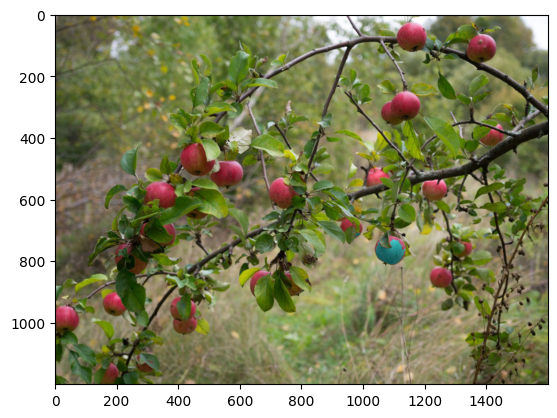

In [149]:
hsv1 = cv2.cvtColor(section, cv2.COLOR_BGR2HSV)

lower = (100, 150, 70)
upper = (170, 255, 255)
mask1 = cv2.inRange(hsv1, lower, upper)
h, s, v = cv2.split(hsv1)
h[mask1 > 0] = 30  
section[:] = cv2.cvtColor(cv2.merge([h, s, v]), cv2.COLOR_HSV2BGR)

plt.imshow(output1)

## 4.

In [150]:
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

x, y = 400, 620  # coordinates of a leaf
print("Leaf HSV:", hsv[y, x])

Leaf HSV: [ 74 251  67]


In [151]:
# HSV range for green leaves
lower = (70, 100, 100)    
upper = (95, 255, 255)  


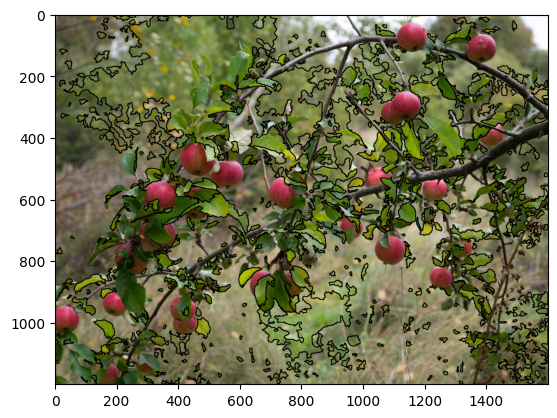

In [152]:
mask = cv2.inRange(hsv, lower, upper)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

# Find contours
cnts = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cnts = imutils.grab_contours(cnts)
cnts = [c for c in cnts if cv2.contourArea(c) > 50]

# Draw results
output = image.copy()
cv2.drawContours(output, cnts, -1, (0, 0, 0), 2)
plt.imshow(output)

width=1280, height=720, depth=3


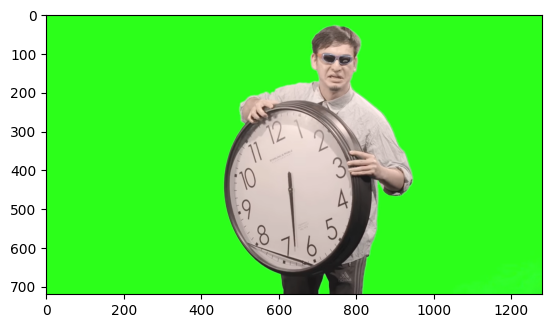

In [153]:
path = "ittsp.png"
bgr_img = cv2.imread(path)

b,g,r = cv2.split(bgr_img)       # get b,g,r
image = cv2.merge([r,g,b])
(h, w, d) = image.shape
print("width={}, height={}, depth={}".format(w, h, d))
plt.imshow(image)

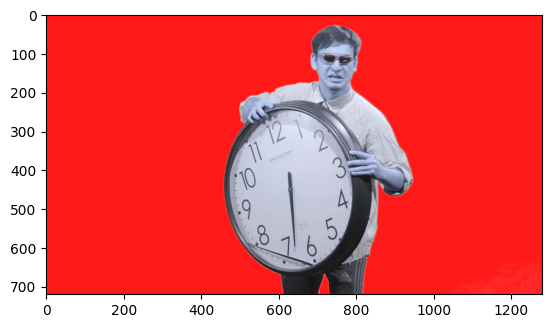

In [154]:
output=image.copy() 
hsv = cv2.cvtColor(output, cv2.COLOR_BGR2HSV)
lower = (35, 80, 80)   
upper = (85, 255, 255)
mask = cv2.inRange(hsv, lower, upper)
h, s, v = cv2.split(hsv)
h[mask > 0] = 0            # red hue
hsv2 = cv2.merge([h, s, v])
output = cv2.cvtColor(hsv2, cv2.COLOR_HSV2BGR)

plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))


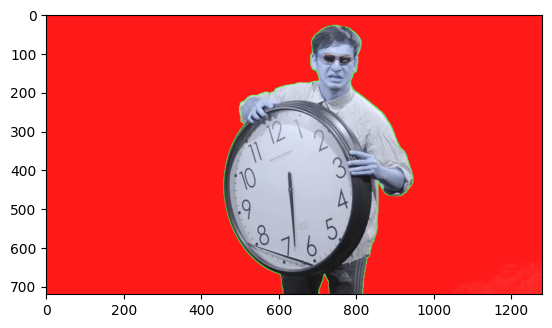

In [156]:
kernel = np.ones((5,5), np.uint8)   # or (3,3) for a lighter touch

# ---- Pick ONE ----
# 1) Remove green/blue halo (shrink the mask a bit)
mask = cv2.erode(mask, kernel, iterations=1)
h, s, v = cv2.split(hsv)
h[mask > 0] = 0            # red hue
hsv2 = cv2.merge([h, s, v])
output = cv2.cvtColor(hsv2, cv2.COLOR_HSV2BGR)

plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))